In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from RENDES_fizinfo import *

In [2]:
def create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g=9.81):

    # konstans tömeg
    def mass_fun(t):   # formai okokból kell a t de ettől nem függ ez a tömeg
        return m

    def force_fun(t, r, v, m):  # formai okokból kell a t, r, v de egyiktől sem függ ez az erőfüggvény
        """Gravitációs erő y irányban és v^2-teal arányos közegellenállási erő eredője
        + talaj felfele ható és fékező ereje."""
        
        F_work=np.array([0.0, -m*g], np.float64)  # grav erő
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs # közegell. erő hatása

        if r[1]<0.0:  # elértük a talajt
            F_work+=np.array([0.0, -D*r[1]])  # rugalmas erő felfele
            F_work-=F_f*v/np.maximum(v_abs, 1e-10)
    
        return F_work

    return force_fun, mass_fun

In [3]:
m_ball=0.59      # 
perim_ball=0.76  # 

r=perim_ball/(2*np.pi)
A=np.pi*r**2
C=0.47 # gömb
rho=1.3 # levegő sűrűség
g=9.81

D=4000.0  # 
F_f=3.0   # egy kis fékeződés a talajjal való érintkezés során

F_ball, m_ball= create_grav_közeg_talaj_F_m(m_ball, C, A, rho, D, F_f, g)

In [4]:
# kezdőértékek
x0=0.0
y0=1.9
v0_x=10.0*np.cos(np.radians(40.0))
v0_y=10.0*np.sin(np.radians(40.0))


# dinamikai számítások
ball_din=num_dinam(2)
ball_din.set_time_range(0.0, 20.0, 0.001)
ball_din.set_mass_fun(m_ball)
ball_din.set_F_fun(F_ball)   
ball_din.set_r0_v0([x0, y0], [v0_x, v0_y])

ball_din.full_dinam_calc()

In [5]:
# a)

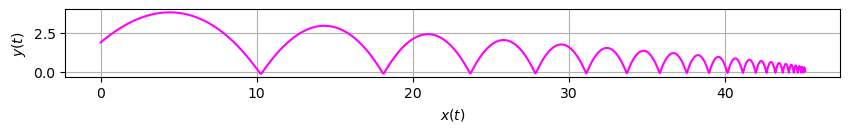

In [6]:
ball_din.plot_rcomp()

In [7]:
# b)

In [8]:
y_work=ball_din.r[:,1]

arg_talaj=arg_eq(y_work, 0.0)

arg_talaj0=arg_talaj[0]

In [9]:
ball_din.v_abs=vect_abs(ball_din.v)

print("Az első talaj-leérés:")
print(f"  - ideje: {ball_din.t[arg_talaj0]:.2f} s.")
print(f"  - x koord: {ball_din.r[arg_talaj0,0]:.2f} m.")
print(f"  - sebessége: {ball_din.v_abs[arg_talaj0]:.2f} m/s.")

Az első talaj-leérés:
  - ideje: 1.52 s.
  - x koord: 10.14 m.
  - sebessége: 9.96 m/s.


In [10]:
# c)

In [11]:
arg_x3m=arg_eq(ball_din.r[:,0] , 3.0)

y_x3m=ball_din.r[ arg_x3m[0] , 1]

if y_x3m>2.6:
    print("Átrepül.")
else:
    print ("Nem repül át.")

Átrepül.


In [12]:
# d)

In [13]:
arg_holtpont=arg_eq(ball_din.v[:,1], 0.0)

In [14]:
for arg in arg_holtpont:
    if ball_din.r[arg, 1]<0.0:
        continue
    print(f"{ball_din.t[arg]:.3f}\t{ball_din.r[arg, 0]:.2f}\t{ball_din.r[arg, 1]:.2f}\t{ball_din.v_abs[arg]:.2f}")

0.615	4.43	3.83	6.81
2.323	14.32	2.97	4.92
3.848	20.96	2.43	3.84
5.240	25.80	2.05	3.13
6.528	29.50	1.77	2.62
7.730	32.41	1.55	2.23
8.859	34.76	1.37	1.92
9.925	36.67	1.22	1.67
10.932	38.25	1.09	1.46
11.888	39.55	0.97	1.27
12.795	40.64	0.88	1.12
13.659	41.54	0.79	0.98
14.481	42.30	0.71	0.85
15.265	42.93	0.65	0.75
16.011	43.45	0.58	0.65
16.721	43.87	0.52	0.56
17.398	44.23	0.47	0.48
18.041	44.51	0.42	0.41
18.652	44.74	0.38	0.34
19.232	44.92	0.34	0.28
19.781	45.06	0.30	0.23


In [15]:
# e)

In [16]:
def dobastav(alpha_deg):
    m_ball=0.59      # 
    perim_ball=0.76  # 

    r=perim_ball/(2*np.pi)
    A=np.pi*r**2
    C=0.47 # gömb
    rho=1.3 # levegő sűrűség
    g=9.81

    D=4000.0  # 
    F_f=3.0   # egy kis fékeződés a talajjal való érintkezés során

    F_ball, m_ball= create_grav_közeg_talaj_F_m(m_ball, C, A, rho, D, F_f, g)
    
    # kezdőértékek
    x0=0.0
    y0=1.9
    v0_x=10.0*np.cos(np.radians(alpha_deg))
    v0_y=10.0*np.sin(np.radians(alpha_deg))

    # dinamikai számítások
    ball_din=num_dinam(2)
    ball_din.set_time_range(0.0, 5.0, 0.001)
    ball_din.set_mass_fun(m_ball)
    ball_din.set_F_fun(F_ball)   
    ball_din.set_r0_v0([x0, y0], [v0_x, v0_y])

    ball_din.full_dinam_calc()
    
    y_work=ball_din.r[:,1]

    arg_talaj=arg_eq(y_work, 0.0)

    arg_talaj0=arg_talaj[0]
    
    dobastav=ball_din.r[arg_talaj0,0]
    
    return dobastav

In [17]:
dobastav(40)

10.142744639329758

In [18]:
tav_max=0.0

for alpha_deg in np.arange(0.0, 90.0, 1.0):
    tav=dobastav(alpha_deg)
    
    if tav>tav_max:
        tav_max=tav
        alpha_deg_max=alpha_deg

In [19]:
print(f"Max. táv: alpha={alpha_deg_max:.2f}°; táv={tav_max:.2f} m.")

Max. táv: alpha=39.00°; táv=10.15 m.
